# Desafio:

Utilize o arquivo enviado em anexo para gerar uma imagem de satélite simulada. É importante que seu código tenha esse bloco enviado no início. Depois, escreva funções para responder e realizar as seguintes operações sobre a matriz imagem_satelite gerada:

* Dimensões e Tipo: Imprima na tela o tamanho total da imagem (número de linhas e colunas) e o tipo de dado dos pixels (dtype);

* Filtro de Máscara de Nuvens: Em imagens com satélites, frequentemente precisamos descartar pixels obstruídos por nuvens. Crie uma lógica que conte quantos pixels na imagem possuem valor maior ou igual a 240 (o que representaria a nossa nuvem simulada). Imprima esse valor e a porcentagem que essa "nuvem" ocupa em relação ao total da imagem;

* Estatística da Região de Interesse: Imagine que o centro da imagem (linhas de 200 a 300, colunas de 200 a 300) seja a região de Porto Alegre. Extraia apenas esse subquadrado da matriz e 
calcule:

  * O valor médio dos pixels nessa região.

  * O valor máximo e o valor mínimo.

In [1]:
import numpy as np

# Configura uma semente para garantir que o resultado seja o mesmo
np.random.seed(42)

# Simula uma matriz de 500x500 pixels
# Os valores variam de 0 a 255 (representando a intensidade do pixel)
imagem_satelite = np.random.randint(0, 256, size=(500, 500))

# Simula uma "nuvem" artificial (região com alta refletividade, valores > 240)
imagem_satelite[100:200, 150:250] = np.random.randint(240, 256, size=(100, 100))

print("Matriz da imagem gerada com sucesso!")

Matriz da imagem gerada com sucesso!


# Solução:

Dimensões e Tipo:

In [2]:
def dimensoesTipo(matriz):
    linhas, colunas = matriz.shape
    dataType = matriz.dtype

    print(f"A matriz tem {linhas} linhas e {colunas} colunas. Os dados são do tipo {dataType}")

In [3]:
dimensoesTipo(imagem_satelite)

A matriz tem 500 linhas e 500 colunas. Os dados são do tipo int32


Filtro de Máscara de Nuvens:

In [ ]:
def filtroNuvens(matriz):
    totalPixels = matriz.size

    #criando a máscara
    mascara = matriz >= 240

    pixelsNuvens = np.sum(mascara)
    porcentagemNuvem = (pixelsNuvens / totalPixels) * 100

    print(f"Total de pixels da nuvem: {pixelsNuvens},  porcentagem de área ocupada: {porcentagemNuvem} %")

In [5]:
filtroNuvens(imagem_satelite)

Total de pixels da numvem: 24866,  porcentagem de área ocupada: 9.9464 %


Estatística da Região de Interesse:

In [6]:
def regiaoDeInteresse(matriz):
    matrizRegiao = matriz[200:300, 200:300]

    valorMedio = np.mean(matrizRegiao)
    valorMax = np.max(matrizRegiao)
    valorMin = np.min(matrizRegiao)

    print(f"Valor mínimo: {valorMin}, valor máximo: {valorMax}, valor médio: {valorMedio} ")

    return(matrizRegiao)

In [7]:
regiaoDeInteresse(imagem_satelite)

Valor mínimo: 0, valor máximo: 255, valor médio: 125.5762 


array([[  2, 200, 132, ...,  24,  93,  36],
       [ 81,  35, 211, ...,   8, 134,  17],
       [ 26,  98,  21, ..., 206, 221, 224],
       ...,
       [194,  91, 207, ..., 229, 161,  43],
       [238, 115,  89, ..., 155,   5, 144],
       [ 85, 139, 154, ...,  37, 101, 102]], shape=(100, 100), dtype=int32)

# Parte fora do desafio

In [8]:
import matplotlib.pyplot as plt

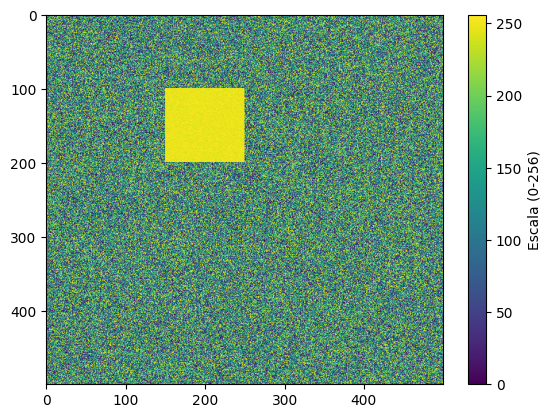

In [9]:
heatmap = plt.imshow(imagem_satelite, cmap="viridis", vmin=0, vmax=256, aspect="auto")
plt.colorbar(heatmap, label="Escala (0-256)")

plt.show()

Matriz Região

Valor mínimo: 0, valor máximo: 255, valor médio: 125.5762 


C:\Users\artur\AppData\Local\Temp\ipykernel_23796\3066223380.py:3: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 3 Axes> than <Figure size 640x480 with 1 Axes> which fig.colorbar is called on.
  plt.colorbar(heatmap, label="Escala (0-256)")


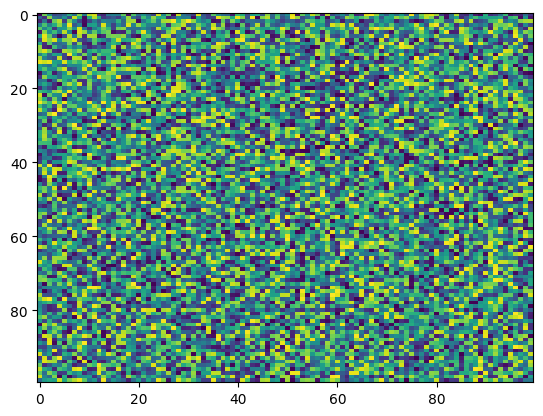

In [10]:
mapaRegiao = regiaoDeInteresse(imagem_satelite)
heatmap2 = plt.imshow(mapaRegiao, cmap="viridis", vmin=0, vmax=256, aspect="auto")
plt.colorbar(heatmap, label="Escala (0-256)")

plt.show()

Segunda função sem ruído

In [11]:
def filtroNuvens2(matriz):
    mascara = (matriz >= 240).astype(float)
    
    janela = 5
    offset = janela // 2
    
    densidade_vizinhos = np.zeros_like(mascara)
    
    for i in range(-offset, offset + 1):
        for j in range(-offset, offset + 1):
            
            densidade_vizinhos += np.roll(np.roll(mascara, i, axis=0), j, axis=1)
            
    mascaraFinal = (mascara == 1) & (densidade_vizinhos >= 15)
    
    pixels_nuvens_reais = np.sum(mascaraFinal)
    total_pixels = matriz.size
    porcentagem_limpa = (pixels_nuvens_reais / total_pixels) * 100
    
    print(f"Total de pixels da nuvem (filtrada): {pixels_nuvens_reais}")
    print(f"Porcentagem de área ocupada real: {porcentagem_limpa:.4f} %")

    return mascaraFinal
    

Total de pixels da nuvem (filtrada): 9988
Porcentagem de área ocupada real: 3.9952 %


C:\Users\artur\AppData\Local\Temp\ipykernel_23796\30279565.py:4: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 4 Axes> than <Figure size 640x480 with 1 Axes> which fig.colorbar is called on.
  plt.colorbar(heatmap, label="Escala (0-256)")


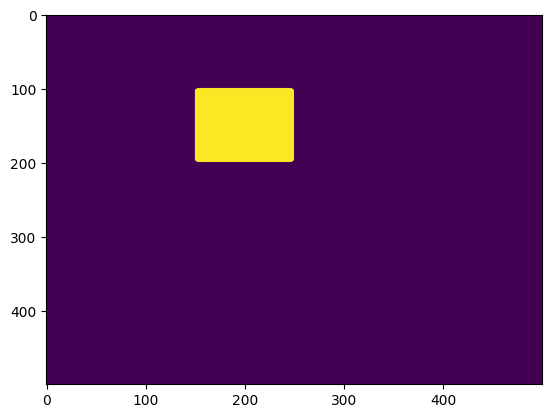

In [12]:
imagemFiltrada = filtroNuvens2(imagem_satelite)

heatmap3 = plt.imshow(imagemFiltrada, cmap="viridis", vmin=0, vmax=1, aspect="auto")
plt.colorbar(heatmap, label="Escala (0-256)")

plt.show()